# Regression in tensorflow exercise


### 1. Create your own regression dataset (or make the one we created in "Create data to view and fit" bigger) and build fit a model to it

In [1]:
import  tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.arange(-100,100,4)
Y = np.arange(-90,110,4)

print(x)
print(Y)


[-100  -96  -92  -88  -84  -80  -76  -72  -68  -64  -60  -56  -52  -48
  -44  -40  -36  -32  -28  -24  -20  -16  -12   -8   -4    0    4    8
   12   16   20   24   28   32   36   40   44   48   52   56   60   64
   68   72   76   80   84   88   92   96]
[-90 -86 -82 -78 -74 -70 -66 -62 -58 -54 -50 -46 -42 -38 -34 -30 -26 -22
 -18 -14 -10  -6  -2   2   6  10  14  18  22  26  30  34  38  42  46  50
  54  58  62  66  70  74  78  82  86  90  94  98 102 106]


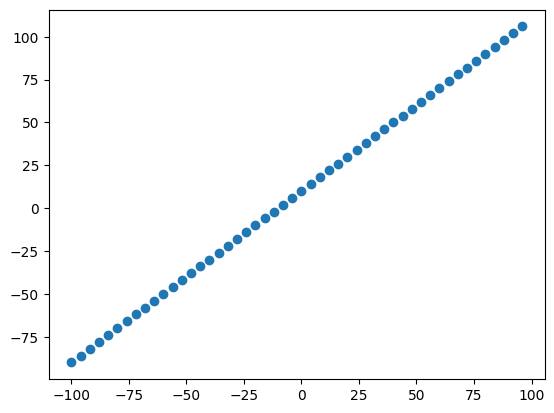

In [3]:
plt.scatter(x, Y)


In [4]:
print(x.shape)
print(Y.shape)

(50,)
(50,)


In [5]:
# let's convert the numpy arrays to tensors
x = tf.constant(x,dtype =tf.float32)
Y = tf.constant(Y,dtype =tf.float32)
print(x)
print(Y)

tf.Tensor(
[-100.  -96.  -92.  -88.  -84.  -80.  -76.  -72.  -68.  -64.  -60.  -56.
  -52.  -48.  -44.  -40.  -36.  -32.  -28.  -24.  -20.  -16.  -12.   -8.
   -4.    0.    4.    8.   12.   16.   20.   24.   28.   32.   36.   40.
   44.   48.   52.   56.   60.   64.   68.   72.   76.   80.   84.   88.
   92.   96.], shape=(50,), dtype=float32)
tf.Tensor(
[-90. -86. -82. -78. -74. -70. -66. -62. -58. -54. -50. -46. -42. -38.
 -34. -30. -26. -22. -18. -14. -10.  -6.  -2.   2.   6.  10.  14.  18.
  22.  26.  30.  34.  38.  42.  46.  50.  54.  58.  62.  66.  70.  74.
  78.  82.  86.  90.  94.  98. 102. 106.], shape=(50,), dtype=float32)


In [6]:
# let's see the differences between the x and Y datapoints
tf.subtract(x,Y).numpy()

array([-10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.,
       -10., -10., -10., -10., -10., -10.], dtype=float32)

### 2. Try building a neural network with 4 Dense layers and fitting it to your own regression dataset, how does it perform?


In [7]:
import tensorflow as tf

# set a random seed
tf.random.set_seed(42)

# create model using Sequential API
regModel = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu", input_shape=(1,)),  # input + hidden
    tf.keras.layers.Dense(1)  # output layer for regression
])

# compile the model
regModel.compile(
    loss=tf.keras.losses.MeanAbsoluteError(),  # or 'mae'
    optimizer=tf.keras.optimizers.SGD(),
    metrics=[tf.keras.metrics.MeanSquaredError()]  # or 'mse'
)

# fit the model
regModel.fit(x, Y, epochs=10)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 41.5296 - mean_squared_error: 2712.9370 
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 22.1582 - mean_squared_error: 730.9485
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 10.5621 - mean_squared_error: 166.5166
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.5804 - mean_squared_error: 29.0040
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16.0335 - mean_squared_error: 375.4756
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.6074 - mean_squared_error: 250.9212
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 11.9967 - mean_squared_error: 191.9979
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.8789 - mean_squared_error: 37.4569
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 13.7774 - mean_squared_error: 337.9786
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 10.2390 - mean_squared_error: 157.6633


In [8]:
regModel.evaluate(x,Y)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.6180 - mean_squared_error: 40.1349 


[5.677304744720459, 39.7431755065918]

### 3.  Try and improve the results we got on the insurance dataset, some things you might want to try include:

* Building a larger model (how does one with 4 dense layers go?).
* Increasing the number of units in each layer
* Lookup the documentation of Adam and find out what the first parameter is, what happens if you increase it by 10x?
* What happens if you train for longer (say 300 epochs instead of 200)?

In [9]:
from os import name
# lets improve the model

# first lets add more dense layers
# set a random seed
tf.random.set_seed(42)

# build the more iwth moredense layers
regModel2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name = "InputLayer"), # Specify input shape here
    tf.keras.layers.Dense(100, activation= "relu"),
    tf.keras.layers.Dense(1100, activation = "relu"),
    tf.keras.layers.Dense(1, activation="tanh")
], name = "model2") # Changed 'model 2' to 'model_2'

# compile the model
regModel2.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(),
    metrics = ["mae"]
)

# fit the model
regModel2.fit(tf.expand_dims(x, axis=-1), Y, epochs =  15) # Reshape x for the Dense layer

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 51.4448 - mae: 51.4448 
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.3842 - mae: 50.3842
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3839 - mae: 50.3839
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3836 - mae: 50.3836
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 50.3833 - mae: 50.3833
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 50.3830 - mae: 50.3830
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 50.3827 - mae: 50.3827
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 50.3824 - mae: 50.3824
Epoch 9/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3821 - mae: 50.3821
Epoch 10/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3818 - mae: 50.3818
Epoch 11/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.3816 - mae: 50.3816
Epoch 12/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3813 - mae: 50.3813
Epoch 13/15
2/2 ━━━━━━━━━━━━━━━━━━━━

In [10]:
regModel2.evaluate(x, Y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 45.3583 - mae: 45.3583 


[49.40700149536133, 49.40700149536133]

### Build same model using the Adam optimizers

In [11]:
# set a random seed
tf.random.set_seed(42)

# build Model
regModel3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name = "InputLayer"), # Specify input shape here
    tf.keras.layers.Dense(100, activation= "relu"),
    tf.keras.layers.Dense(1100, activation = "relu"),
    tf.keras.layers.Dense(1, activation="tanh")
], name = "model2") # Changed 'model 2' to 'model_2'

# compile the model
regModel3.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(),
    metrics =  ["mae"]
)
# fit the model
regModel3.fit(x, Y, epochs = 200, verbose=1)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 51.6936 - mae: 51.6936
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 50.3942 - mae: 50.3942
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3922 - mae: 50.3922
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3911 - mae: 50.3911
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.3903 - mae: 50.3903
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.3894 - mae: 50.3894
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.3884 - mae: 50.3884
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.3871 - mae: 50.3871
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3856 - mae: 50.3856
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 50.3833 - mae: 50.3833
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.3797 - mae: 50.3797
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.3725 - mae: 50.3725
Epoch 13/200
2/2 ━━━━━━━━

In [12]:
# evaluate the model
regModel3.evaluate(x, Y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 45.2553 - mae: 45.2553 


[49.32022476196289, 49.32022476196289]

In [13]:
print(x)
print(Y)

tf.Tensor(
[-100.  -96.  -92.  -88.  -84.  -80.  -76.  -72.  -68.  -64.  -60.  -56.
  -52.  -48.  -44.  -40.  -36.  -32.  -28.  -24.  -20.  -16.  -12.   -8.
   -4.    0.    4.    8.   12.   16.   20.   24.   28.   32.   36.   40.
   44.   48.   52.   56.   60.   64.   68.   72.   76.   80.   84.   88.
   92.   96.], shape=(50,), dtype=float32)
tf.Tensor(
[-90. -86. -82. -78. -74. -70. -66. -62. -58. -54. -50. -46. -42. -38.
 -34. -30. -26. -22. -18. -14. -10.  -6.  -2.   2.   6.  10.  14.  18.
  22.  26.  30.  34.  38.  42.  46.  50.  54.  58.  62.  66.  70.  74.
  78.  82.  86.  90.  94.  98. 102. 106.], shape=(50,), dtype=float32)


In [14]:
print(x-Y)

tf.Tensor(
[-10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10.
 -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10.
 -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10.
 -10. -10. -10. -10. -10. -10. -10. -10.], shape=(50,), dtype=float32)


In [15]:
regModel.predict(tf.constant([-96.]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([[-85.67592]], dtype=float32)

## lets create a bigger Dataset

In [16]:
# input values of the bigger dataset
X_ = tf.range(-300, 300, 5 )
X_

<tf.Tensor: shape=(120,), dtype=int32, numpy=
array([-300, -295, -290, -285, -280, -275, -270, -265, -260, -255, -250,
       -245, -240, -235, -230, -225, -220, -215, -210, -205, -200, -195,
       -190, -185, -180, -175, -170, -165, -160, -155, -150, -145, -140,
       -135, -130, -125, -120, -115, -110, -105, -100,  -95,  -90,  -85,
        -80,  -75,  -70,  -65,  -60,  -55,  -50,  -45,  -40,  -35,  -30,
        -25,  -20,  -15,  -10,   -5,    0,    5,   10,   15,   20,   25,
         30,   35,   40,   45,   50,   55,   60,   65,   70,   75,   80,
         85,   90,   95,  100,  105,  110,  115,  120,  125,  130,  135,
        140,  145,  150,  155,  160,  165,  170,  175,  180,  185,  190,
        195,  200,  205,  210,  215,  220,  225,  230,  235,  240,  245,
        250,  255,  260,  265,  270,  275,  280,  285,  290,  295],
      dtype=int32)>

In [17]:
# make the label of the dataset
y_ = X_ + 100
y_

<tf.Tensor: shape=(120,), dtype=int32, numpy=
array([-200, -195, -190, -185, -180, -175, -170, -165, -160, -155, -150,
       -145, -140, -135, -130, -125, -120, -115, -110, -105, -100,  -95,
        -90,  -85,  -80,  -75,  -70,  -65,  -60,  -55,  -50,  -45,  -40,
        -35,  -30,  -25,  -20,  -15,  -10,   -5,    0,    5,   10,   15,
         20,   25,   30,   35,   40,   45,   50,   55,   60,   65,   70,
         75,   80,   85,   90,   95,  100,  105,  110,  115,  120,  125,
        130,  135,  140,  145,  150,  155,  160,  165,  170,  175,  180,
        185,  190,  195,  200,  205,  210,  215,  220,  225,  230,  235,
        240,  245,  250,  255,  260,  265,  270,  275,  280,  285,  290,
        295,  300,  305,  310,  315,  320,  325,  330,  335,  340,  345,
        350,  355,  360,  365,  370,  375,  380,  385,  390,  395],
      dtype=int32)>

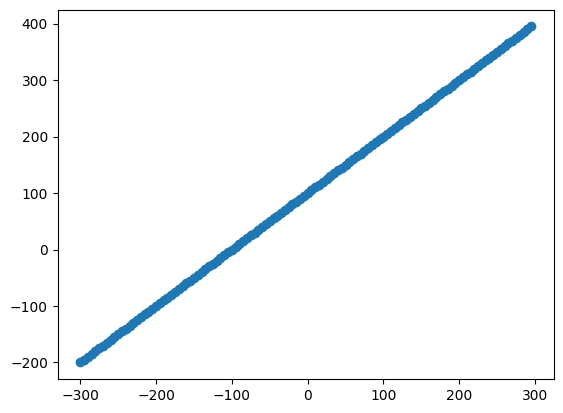

In [18]:
# visualize the dataset
import matplotlib.pyplot as plt

plt.scatter(X_, y_)

In [19]:
# lets check the shape and the lenght of the dtaset
X_.shape, y_.shape

(TensorShape([120]), TensorShape([120]))

In [20]:
# print the length dataset
len(X_)

120

In [21]:
# Split the dataset into training and testing set
X_train = X_[:90]
y_train = y_[:90]

X_test = X_[90:]
y_test = y_[90:]

In [22]:
# check the shape of the training and testing dataset
len(X_train), len(y_train), len(X_test), len(y_test)

(90, 90, 30, 30)

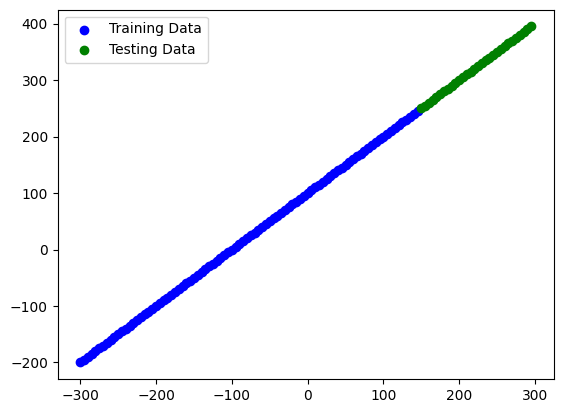

In [23]:
# visualizing the data

# visulaize the training data
plt.scatter(X_train, y_train, c="b", label="Training Data")

# visualize the testing data
plt.scatter(X_test, y_test,c="g", label = "Testing Data")

# show the legend
plt.legend();

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import MeanSquaredError as mse
from tensorflow.keras.optimizers import Adam, SGD


In [25]:
# build the base line model

model_1 = Sequential([
    Dense(1),
])

# compile the model
model_1.compile(
    loss = mse(),
    metrics = ["mse"]
)

# fit the model
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs= 50,  verbose=0)

In [26]:
# evaluate the base line model
model_1.evaluate(X_train, y_train)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 17160.7070 - mse: 17160.7070 


[18673.185546875, 18673.185546875]

In [27]:
# get the model summary
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4 (20.00 B)

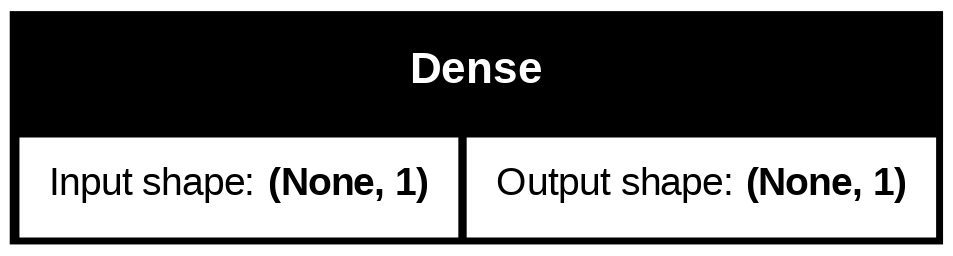

In [28]:
# plot model visually
from tensorflow.keras.utils import plot_model

plot_model(model=model_1, show_shapes=True)

In [29]:
# visulizing the model predictions

y_model_1_pred = model_1.predict(X_test)
y_model_1_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[ -6.157151 ],
       [ -6.3649364],
       [ -6.5727215],
       [ -6.7805066],
       [ -6.9882913],
       [ -7.1960764],
       [ -7.4038615],
       [ -7.6116467],
       [ -7.819432 ],
       [ -8.027216 ],
       [ -8.235002 ],
       [ -8.442786 ],
       [ -8.650572 ],
       [ -8.858356 ],
       [ -9.066141 ],
       [ -9.273927 ],
       [ -9.481711 ],
       [ -9.689497 ],
       [ -9.897282 ],
       [-10.105066 ],
       [-10.312852 ],
       [-10.520637 ],
       [-10.728422 ],
       [-10.936207 ],
       [-11.143992 ],
       [-11.351777 ],
       [-11.559562 ],
       [-11.767347 ],
       [-11.975132 ],
       [-12.182918 ]], dtype=float32)

In [30]:
X_train[:30]

<tf.Tensor: shape=(30,), dtype=int32, numpy=
array([-300, -295, -290, -285, -280, -275, -270, -265, -260, -255, -250,
       -245, -240, -235, -230, -225, -220, -215, -210, -205, -200, -195,
       -190, -185, -180, -175, -170, -165, -160, -155], dtype=int32)>

In [31]:
y_model_1_pred.shape

(30, 1)

In [32]:
y_train

<tf.Tensor: shape=(90,), dtype=int32, numpy=
array([-200, -195, -190, -185, -180, -175, -170, -165, -160, -155, -150,
       -145, -140, -135, -130, -125, -120, -115, -110, -105, -100,  -95,
        -90,  -85,  -80,  -75,  -70,  -65,  -60,  -55,  -50,  -45,  -40,
        -35,  -30,  -25,  -20,  -15,  -10,   -5,    0,    5,   10,   15,
         20,   25,   30,   35,   40,   45,   50,   55,   60,   65,   70,
         75,   80,   85,   90,   95,  100,  105,  110,  115,  120,  125,
        130,  135,  140,  145,  150,  155,  160,  165,  170,  175,  180,
        185,  190,  195,  200,  205,  210,  215,  220,  225,  230,  235,
        240,  245], dtype=int32)>

In [37]:
# visulaie the training and testing and predicition

def plot_preditions(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels=y_test,
                    predictions = y_model_1_pred):
  """
  Plot training , testing data point and compare with predictions with ground truth
  """

  plt.figure(figsize=(12,8))
  # plot the training data point in blue
  plt.scatter(X_train, y_train, c="b", label ="training_points")
  # plot the testing data point in green
  plt.scatter(X_test,y_test, c="g", label = "testing_points")
  # plot the predictions data point in red
  plt.scatter(X_test, y_model_1_pred, c="r", label = "Predictions_points")
  #show legend
  plt.legend()

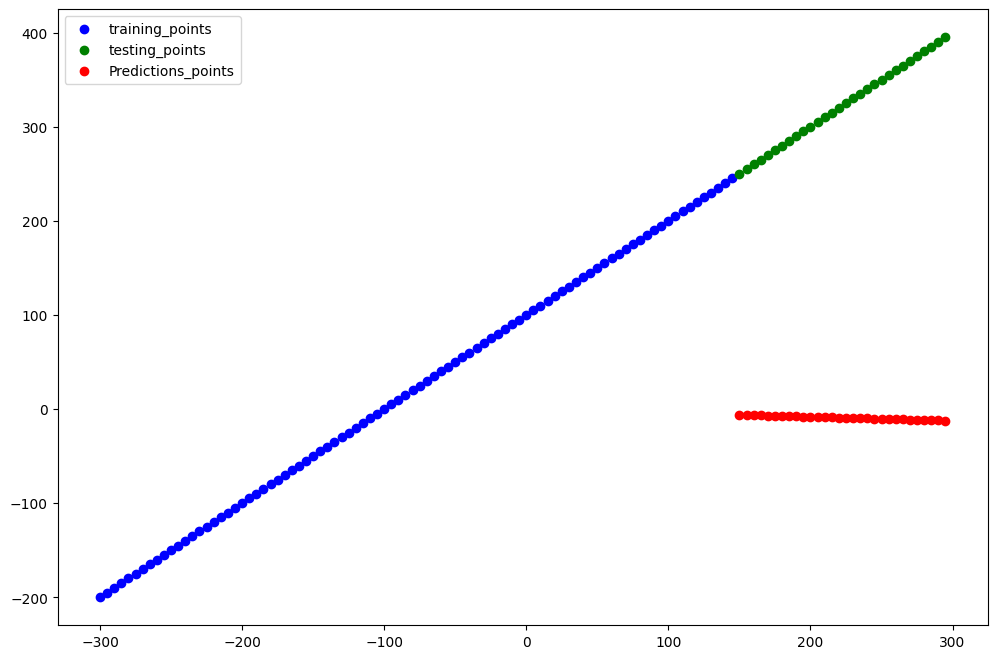

In [38]:
plot_preditions(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels=y_test,
                    predictions = y_model_1_pred)

we can see the model in performing badbly, so we can build more sophiscated models and turned parameters